In [3]:
import time
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from xrfm import xRFM
warnings.filterwarnings('ignore')

In [4]:
class SklearnCompatibleXRFM(BaseEstimator, RegressorMixin):
    def __init__(self, bandwidth=1.0, reg=1e-3, iters=3, n_trees=5, random_state=42):
        self.bandwidth = bandwidth
        self.reg = reg
        self.iters = iters
        self.n_trees = n_trees
        self.random_state = random_state
        self.model_ = None

    def fit(self, X, y):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        rfm_params = {
            'model': {
                'kernel': 'l2',
                'bandwidth': self.bandwidth,
                'bandwidth_mode': 'constant',
            },
            'fit': {
                'reg': self.reg,
                'iters': 1,
                'verbose': False,
            }
        }

        self.model_ = xRFM(
            task='regression',
            n_trees=self.n_trees,
            n_tree_iters=self.iters,
            rfm_params=rfm_params,
            device=device,
            tuning_metric='mse'
        )

        split_idx = int(len(X) * 0.8)
        X_tr, X_v = X[:split_idx], X[split_idx:]
        y_tr, y_v = y[:split_idx], y[split_idx:]

        y_tr_padded = np.stack([y_tr, np.zeros_like(y_tr)], axis=1)
        y_v_padded = np.stack([y_v, np.zeros_like(y_v)], axis=1)

        self.model_.fit(X_tr, y_tr_padded, X_v, y_v_padded)
        return self

    def predict(self, X):
        preds = self.model_.predict(X)
        if hasattr(preds, 'cpu'):
            preds = preds.cpu().numpy()


        if len(preds.shape) == 2 and preds.shape[1] == 2:
            return preds[:, 0]
        return preds

In [5]:
print("Fetching and Engineering Macro Data...")
SEED = 42
np.random.seed(SEED)

# A basket of diverse macro ETFs
tickers = ['SPY', 'QQQ', 'IWM', 'EFA', 'TLT', 'GLD']
TARGET_WINDOW = 5 # Predict Realized Volatility over the next 5 days

df_list = []

for ticker in tickers:
    # Download 20 years of daily data
    raw_data = yf.download(ticker, start="2004-01-01", end="2024-01-01", progress=False)
    if raw_data.empty: continue

    t_df = raw_data.reset_index()

    if isinstance(t_df.columns, pd.MultiIndex):
        t_df.columns = [col[0] for col in t_df.columns]

    t_df = t_df[['Date', 'Close', 'Volume']].copy()
    t_df['Ticker'] = ticker

    # Base Log Returns
    t_df['log_ret'] = np.log(t_df['Close'] / t_df['Close'].shift(1))

    # Historical Realized Volatility Features
    t_df['vol_5d'] = np.sqrt((t_df['log_ret']**2).rolling(5).sum())
    t_df['vol_21d'] = np.sqrt((t_df['log_ret']**2).rolling(21).sum())

    # Momentum Features
    t_df['mom_5d'] = t_df['Close'] / t_df['Close'].shift(5) - 1
    t_df['mom_21d'] = t_df['Close'] / t_df['Close'].shift(21) - 1

    # Moving Average Distances
    t_df['ma_dist_20d'] = t_df['Close'] / t_df['Close'].rolling(20).mean() - 1
    t_df['ma_dist_50d'] = t_df['Close'] / t_df['Close'].rolling(50).mean() - 1

    # Volume Surges
    t_df['vol_surge_5d'] = t_df['Volume'] / t_df['Volume'].rolling(5).mean() - 1

    # Target: True 5-Day Forward Realized Volatility
    t_df['target_volatility'] = np.sqrt((t_df['log_ret']**2).rolling(TARGET_WINDOW).sum()).shift(-TARGET_WINDOW) * 10000

    t_df = t_df.dropna()
    df_list.append(t_df)

# Combine all datasets and sort strictly by Date to prevent chronological leakage
master_df = pd.concat(df_list).sort_values('Date').reset_index(drop=True)

feature_names = [
    'vol_5d', 'vol_21d', 'mom_5d', 'mom_21d',
    'ma_dist_20d', 'ma_dist_50d', 'vol_surge_5d'
]

X_raw = master_df[feature_names].values
y_raw = master_df['target_volatility'].values

print(f"Total rows gathered: {len(X_raw)}")

Fetching and Engineering Macro Data...
Total rows gathered: 29652


In [6]:
n = len(X_raw)
train_idx = int(n * 0.6)
val_idx = int(n * 0.8)

X_train, y_train = X_raw[:train_idx], y_raw[:train_idx]
X_val, y_val = X_raw[train_idx:val_idx], y_raw[train_idx:val_idx]
X_test, y_test = X_raw[val_idx:], y_raw[val_idx:]

# Drop the overlapping target windows at the split boundaries
X_train, y_train = X_train[:-TARGET_WINDOW], y_train[:-TARGET_WINDOW]
X_val, y_val = X_val[:-TARGET_WINDOW], y_val[:-TARGET_WINDOW]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Subsample strictly for hyperparameter tuning speed
tune_sample_size = min(8000, len(X_train_scaled))
train_tune_size = int(tune_sample_size * 0.8)
val_tune_size = tune_sample_size - train_tune_size

# Take the most recent continuous block of training data, and the start of val data
X_tune_sub = np.vstack((X_train_scaled[-train_tune_size:], X_val_scaled[:val_tune_size]))
y_tune_sub = np.concatenate((y_train[-train_tune_size:], y_val[:val_tune_size]))

test_fold_sub = np.concatenate([-1 * np.ones(train_tune_size), np.zeros(val_tune_size)])
ps_sub = PredefinedSplit(test_fold_sub)

models = {
    'xRFM': (
        SklearnCompatibleXRFM(random_state=SEED),
        {
            'bandwidth': [0.1, 0.5, 1.0, 5.0, 10.0],
            'reg': [1e-5, 1e-3, 1e-1],
            'iters': [3, 5, 10],
            'n_trees': [3, 5, 10]
        }
    ),

    'XGBoost': (
        XGBRegressor(random_state=SEED, objective='reg:squarederror', tree_method='hist', device='cuda' if torch.cuda.is_available() else 'cpu'),
        {
            'n_estimators': [100, 200, 500],
            'max_depth': [3, 6, 9],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 1.0]
        }
    ),
    'MLP': (
        MLPRegressor(random_state=SEED, max_iter=500, early_stopping=True),
        {
            'hidden_layer_sizes': [(64,), (128, 64), (256, 128, 64)],
            'alpha': np.logspace(-5, -1, 5),
            'learning_rate_init': [1e-3, 5e-4, 1e-4]
        }
    )
}

In [7]:
best_models = {}

for name, (model, params) in models.items():
    print(f"\n Tuning {name} ")
    current_jobs = 1 if name in ['xRFM', 'XGBoost'] else -1

    search = RandomizedSearchCV(
        model, param_distributions=params, n_iter=10, cv=ps_sub,
        scoring='neg_root_mean_squared_error', random_state=SEED, n_jobs=current_jobs
    )
    search.fit(X_tune_sub, y_tune_sub)
    best_models[name] = search.best_estimator_
    print(f"Best Params for {name}: {search.best_params_}")


 Tuning xRFM 
None
Fitting xRFM with 10 trees and 5 iterations per tree


Building trees:   0%|          | 0/10 [00:00<?, ?it/s]

Fitting RFM with ntrain: 5120, d: 7, and nval: 1280
Using cheap batch size
Optimal M batch size: 5120
Using SVD
Time taken for round 0: 8.663796186447144 seconds
Using hard routing for tree prediction



Iterating tree:   0%|          | 0/5 [00:00<?, ?it/s]

Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 4900, d: 7, and nval: 1500
Using cheap batch size
Optimal M batch size: 4900
Using SVD
Time taken for round 0: 5.909469127655029 seconds


...


Iterating tree:  67%|██████▋   | 2/3 [00:14<00:07,  7.23s/it]

Using hard routing for tree prediction
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 6400, d: 7, and nval: 1600
Using cheap batch size
Optimal M batch size: 6400
Using SVD
Time taken for round 0: 3.592414617538452 seconds



Building trees:   0%|          | 0/3 [00:28<?, ?it/s]

Using hard routing for tree prediction
==========================Tree iteration results==========================
Validation scores over tree iterations: [4647.6611328125, 4647.6611328125, 4647.6611328125, 4647.6611328125]
Best validation score: 4647.6611328125
Tree has no split, stopping training
Best Params for xRFM: {'reg': 0.1, 'n_trees': 3, 'iters': 3, 'bandwidth': 10.0}

 Tuning XGBoost 


Best Params for XGBoost: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}

 Tuning MLP 
Best Params for MLP: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 64), 'alpha': np.float64(0.0001)}


In [10]:
print("\nGenerating Results")
results_data = {}

for name, model in best_models.items():
    # Record Training Time
    start_time = time.time()
    X_full_train = np.vstack((X_train_scaled, X_val_scaled))
    y_full_train = np.concatenate((y_train, y_val))

    model.fit(X_full_train, y_full_train)
    train_time = time.time() - start_time

    # Record Inference Time
    start_time = time.time()
    preds = model.predict(X_test_scaled)
    inf_time_per_sample = (time.time() - start_time) / len(X_test_scaled)

    # Calculate Normalised RMSE
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    nrmse = rmse / np.std(y_test)

    results_data[(name, 'nRMSE')] = round(nrmse, 4)
    results_data[(name, 'Train Time (s)')] = round(train_time, 2)
    results_data[(name, 'Inference/Sample (s)')] = f"{inf_time_per_sample:.6f}"

results_df = pd.DataFrame([results_data], index=['Macro_ETFs_Daily'])
results_df.columns = pd.MultiIndex.from_tuples(results_df.columns)
display(results_df)


Generating Results
None
Fitting xRFM with 3 trees and 3 iterations per tree


Building trees:   0%|          | 0/3 [00:00<?, ?it/s]

Fitting RFM with ntrain: 18968, d: 7, and nval: 4743
Using cheap batch size
Optimal M batch size: 10000
Using SVD
Time taken for round 0: 86.98478364944458 seconds
Using hard routing for tree prediction



Iterating tree:   0%|          | 0/3 [00:00<?, ?it/s]

Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 18968, d: 7, and nval: 4743
Using cheap batch size
Optimal M batch size: 10000
Using SVD
Time taken for round 0: 77.65238523483276 seconds
Using hard routing for tree prediction


...


Iterating tree:  67%|██████▋   | 2/3 [04:56<02:27, 147.81s/it]

Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 18968, d: 7, and nval: 4743
Using cheap batch size
Optimal M batch size: 10000
Using SVD
Time taken for round 0: 76.25551652908325 seconds
Using hard routing for tree prediction



Building trees:   0%|          | 0/3 [10:00<?, ?it/s]


==========================Tree iteration results==========================
Validation scores over tree iterations: [3036.1767578125, 3036.1767578125, 3036.1767578125, 3036.1767578125]
Best validation score: 3036.1767578125
Tree has no split, stopping training
Using hard routing for tree prediction


xRFM                                     XGBoost  \
                   nRMSE Train Time (s) Inference/Sample (s)   nRMSE   
Macro_ETFs_Daily  0.7197         600.21             0.000153  0.7302   

                                                         MLP                 \
                 Train Time (s) Inference/Sample (s)   nRMSE Train Time (s)   
Macro_ETFs_Daily           0.46             0.000004  0.7216          16.97   

                                       
                 Inference/Sample (s)  
Macro_ETFs_Daily             0.000003

In [11]:

print("\n Running Interpretability Analysis")
X_interp = X_test_scaled
y_interp = y_test

# Standard MI, PCA, and XGBoost Permutation
mi_scores = mutual_info_regression(X_interp, y_interp, random_state=SEED)
pca = PCA(n_components=1).fit(X_interp)
pca_loadings = np.abs(pca.components_[0])
perm_importance_xgb = permutation_importance(best_models['XGBoost'], X_interp, y_interp, n_repeats=5, random_state=SEED, n_jobs=-1)

# xRFM AGOP Extractio
xrfm_agop_diagonals = np.zeros(len(feature_names))
xrfm_base = best_models['xRFM'].model_

try:
    if hasattr(xrfm_base, 'trees') and xrfm_base.trees is not None:
        all_tree_Ms = []

        for tree in xrfm_base.trees:
            try:
                # Attempt to use the model's internal averaging method for this specific tree
                if hasattr(xrfm_base, '_average_M_across_leaves'):
                    m_matrix = xrfm_base._average_M_across_leaves(tree)
                else:
                    # Manual fallback: Find M inside the tree's leaf models
                    # This depends on if 'tree' has a 'leaves' attribute
                    leaf_ms = []
                    leaves = tree.leaves if hasattr(tree, 'leaves') else []
                    for leaf in leaves:
                        if hasattr(leaf, 'model') and hasattr(leaf.model, 'M'):
                            leaf_ms.append(leaf.model.M.detach().cpu().numpy())
                    m_matrix = np.mean(leaf_ms, axis=0) if leaf_ms else None

                if m_matrix is not None:
                    if hasattr(m_matrix, 'detach'): m_matrix = m_matrix.detach().cpu().numpy()
                    all_tree_Ms.append(m_matrix)
            except:
                continue

        if all_tree_Ms:
            mean_M = np.mean(all_tree_Ms, axis=0)
            xrfm_agop_diagonals = np.diag(mean_M) if mean_M.ndim == 2 else mean_M
            print(f"Success: Extracted AGOP from {len(all_tree_Ms)} ensemble trees.")
    else:
        print("No trees found in the xRFM model object.")

except Exception as e:
    print(f"Extraction failed: {e}")

# Normalization for visual comparison
if np.max(np.abs(xrfm_agop_diagonals)) > 0:
    xrfm_agop_diagonals = np.abs(xrfm_agop_diagonals) / np.max(np.abs(xrfm_agop_diagonals))

interp_df = pd.DataFrame({
    'Feature': feature_names,
    'Mutual_Info': mi_scores,
    'PCA_Loading_PC1': pca_loadings,
    'XGB_Permutation': perm_importance_xgb.importances_mean,
    'xRFM_AGOP_Diag': xrfm_agop_diagonals
})

interp_df = interp_df.sort_values(by='XGB_Permutation', ascending=False)
display(interp_df)


 Running Interpretability Analysis
Success: Extracted AGOP from 1 ensemble trees.


,Feature,Mutual_Info,PCA_Loading_PC1,XGB_Permutation,xRFM_AGOP_Diag
1,vol_21d,0.286312,0.211567,0.356531,1.000000
0,vol_5d,0.254282,0.293435,0.078950,0.328759
5,ma_dist_50d,0.155304,0.494786,0.073741,0.434049
4,ma_dist_20d,0.136951,0.502928,0.030392,0.426086
2,mom_5d,0.101166,0.356759,0.011696,0.228395
6,vol_surge_5d,0.015432,0.023880,0.000007,0.184246
3,mom_21d,0.132551,0.493497,-0.000931,0.241239


In [12]:
print("\n Running Scalability Experiment")
# Generate sample steps up to the maximum available training data
max_train = len(X_train_scaled)
sample_sizes = [2500, 5000, 10000, max_train]
scale_results = {name: {'times': [], 'nrmses': []} for name in best_models.keys()}

for size in sample_sizes:
    print(f"Testing N = {size}...")
    X_sub = X_train_scaled[:size]
    y_sub = y_train[:size]

    for name, model in best_models.items():
        if name == 'xRFM' and hasattr(model, 'n_jobs'):
            model.n_jobs = 1

        start = time.time()
        model.fit(X_sub, y_sub)
        train_t = time.time() - start

        preds = model.predict(X_test_scaled)
        nrmse = np.sqrt(mean_squared_error(y_test, preds)) / np.std(y_test)

        scale_results[name]['times'].append(train_t)
        scale_results[name]['nrmses'].append(nrmse)


 Running Scalability Experiment
Testing N = 2500...
None
Fitting xRFM with 3 trees and 3 iterations per tree


Building trees:   0%|          | 0/3 [00:00<?, ?it/s]

Fitting RFM with ntrain: 2000, d: 7, and nval: 500
Using cheap batch size
Optimal M batch size: 2000
Using SVD
Time taken for round 0: 0.20326924324035645 seconds
Using hard routing for tree prediction



Iterating tree:   0%|          | 0/3 [00:00<?, ?it/s]

Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 1600, d: 7, and nval: 900


...

Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 14228, d: 7, and nval: 3558
Using cheap batch size
Optimal M batch size: 10000
Using SVD
Time taken for round 0: 34.2951226234436 seconds
Using hard routing for tree prediction



Iterating tree:  67%|██████▋   | 2/3 [02:10<01:05, 65.28s/it]

Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 14228, d: 7, and nval: 3558
Using cheap batch size
Optimal M batch size: 10000
Using SVD
Time taken for round 0: 34.851988792419434 seconds
Using hard routing for tree prediction



Building trees:   0%|          | 0/3 [04:20<?, ?it/s]


==========================Tree iteration results==========================
Validation scores over tree iterations: [3368.39013671875, 3368.39013671875, 3368.39013671875, 3368.39013671875]
Best validation score: 3368.39013671875
Tree has no split, stopping training
Using hard routing for tree prediction


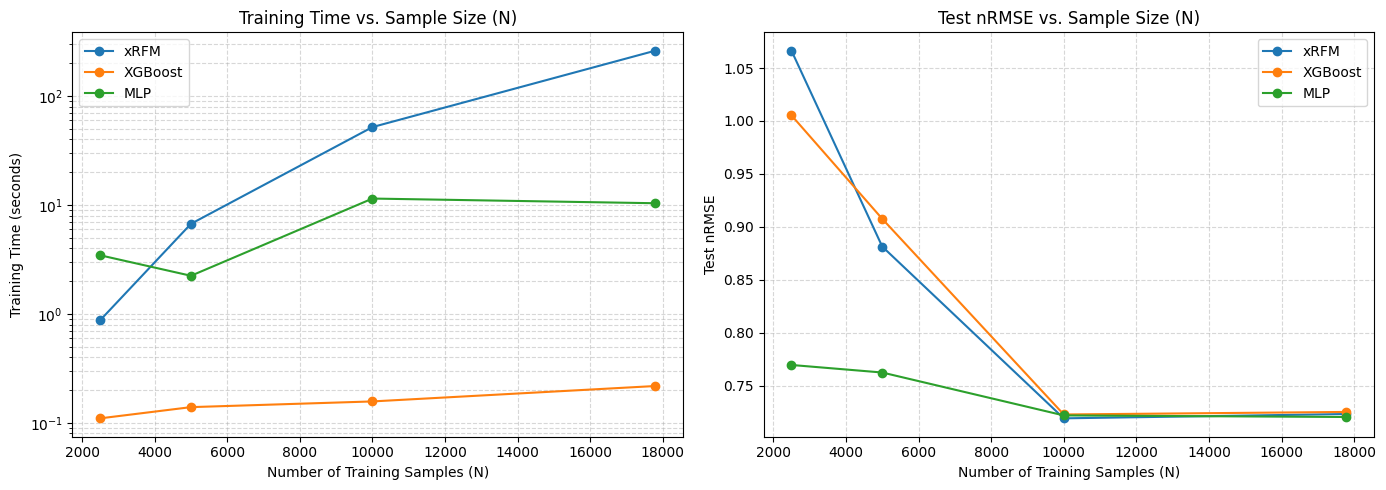

In [13]:
#Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in best_models.keys():
    ax1.plot(sample_sizes, scale_results[name]['times'], marker='o', label=name)
ax1.set_title('Training Time vs. Sample Size (N)')
ax1.set_xlabel('Number of Training Samples (N)')
ax1.set_ylabel('Training Time (seconds)')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.5)

for name in best_models.keys():
    ax2.plot(sample_sizes, scale_results[name]['nrmses'], marker='o', label=name)
ax2.set_title('Test nRMSE vs. Sample Size (N)')
ax2.set_xlabel('Number of Training Samples (N)')
ax2.set_ylabel('Test nRMSE')
ax2.legend()
ax2.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()